# Reference Signal Generators

Reference signals are used to test and characterise DSP systems rather than to produce musical sound. They represent the extremes of the frequency axis and are particularly useful for verifying anti-aliasing filters, measuring frequency responses, and checking DC behaviour.

| Function | Description |
| --- | --- |
| `generate_dc` | Constant signal at a fixed `amplitude`. Tests DC gain, DC-rejection filters, and bias removal. H(0) for any LTI system equals output/input for a DC signal. |
| `generate_nyquist` | Alternating +1/−1 at **every sample** (fs/2 Hz). The highest representable discrete frequency; used to check Nyquist-frequency gain and anti-imaging behaviour. |
| `generate_half_nyquist` | Repeating pattern +1/+1/−1/−1 (fs/4 Hz). Two-sample pairs; convenient for testing sub-Nyquist filter boundaries. |
| `generate_quarter_nyquist` | Eight-sample period at fs/8 Hz. Further below Nyquist; useful for filter roll-off characterisation at known frequencies. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import (
    generate_dc,
    generate_half_nyquist,
    generate_nyquist,
    generate_quarter_nyquist,
)

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Four sub-plots, each displaying a very short window with individual sample dots to show the discrete nature of the signals.

**DC (5 ms):** flat horizontal line at amplitude = 1.0 — confirms that the generator output is truly constant, with no transient at the start

**Nyquist (0.1 ms, 4 samples shown):** alternating ±1 every sample — the fastest oscillation a discrete system can represent; any filter should pass or reject this frequency predictably

**Half-Nyquist (0.2 ms, 8 samples shown):** two consecutive +1 samples then two −1 samples — the caret pattern is clearly visible when individual sample dots are displayed

**Quarter-Nyquist (0.2 ms, 8 samples shown):** eight samples per cycle; sitting at fs/8 Hz (≈ 5.5 kHz at 44 100 Hz)

These four signals together span DC, high-audio, and the two intermediate reference frequencies. Together they provide coverage for any filter measurement that needs exact, analytically known input frequencies.


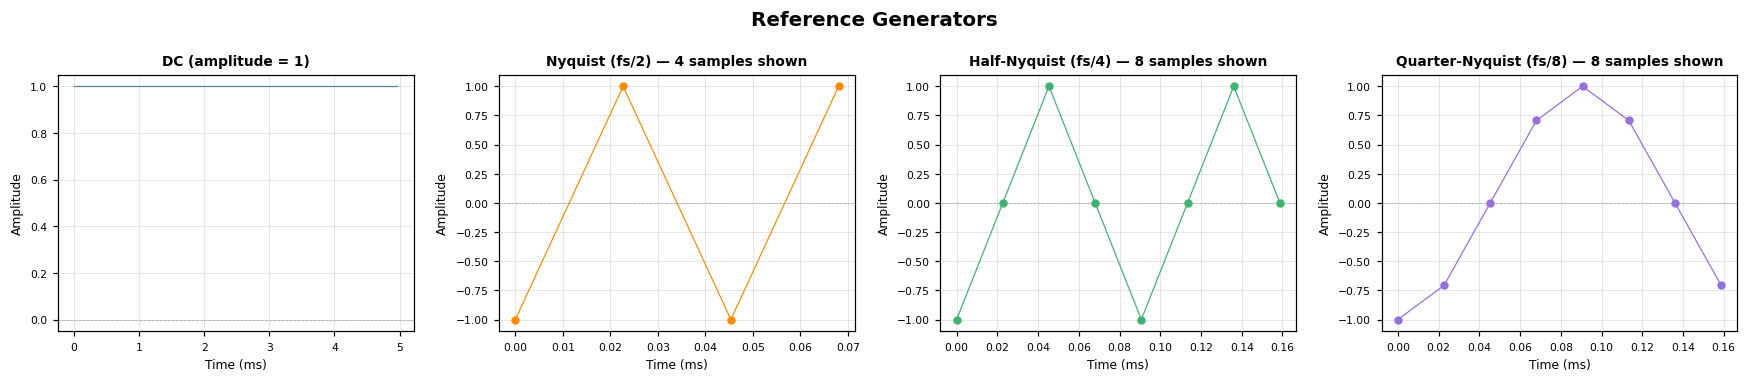

In [2]:
def _ms(ms: float) -> float:
    return ms / 1000.0


FS = 44100

PLOTS = [
    {
        "title": "DC (amplitude = 1)",
        "fn": lambda: generate_dc(fs=FS, duration=_ms(5), amplitude=1.0),
        "color": "steelblue",
    },
    {
        "title": "Nyquist (fs/2) — 4 samples shown",
        "fn": lambda: generate_nyquist(fs=FS, duration=_ms(0.1)),
        "color": "darkorange",
    },
    {
        "title": "Half-Nyquist (fs/4) — 8 samples shown",
        "fn": lambda: generate_half_nyquist(fs=FS, duration=_ms(0.2)),
        "color": "mediumseagreen",
    },
    {
        "title": "Quarter-Nyquist (fs/8) — 8 samples shown",
        "fn": lambda: generate_quarter_nyquist(fs=FS, duration=_ms(0.2)),
        "color": "mediumpurple",
    },
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, spec in zip(axes, PLOTS):
    t, wave = spec["fn"]()
    ax.plot(t * 1000, wave, linewidth=0.8, color=spec["color"])
    # Show individual samples as dots for the Nyquist-family signals
    if len(wave) <= 12:
        ax.scatter(t * 1000, wave, s=20, color=spec["color"], zorder=5)
    ax.set_title(spec["title"], fontsize=9, fontweight="bold")
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)

fig.suptitle("Reference Generators", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Half-Nyquist (fs/4) and quarter-Nyquist (fs/8) reference tones are audible test frequencies. DC and Nyquist (fs/2) are inaudible and omitted.


In [3]:
from IPython.display import Audio, display

_, hn_a = generate_half_nyquist(fs=FS, duration=2.0)     # fs/4 = 11025 Hz
_, qn_a = generate_quarter_nyquist(fs=FS, duration=2.0)  # fs/8 = 5512 Hz

print(f"Half-Nyquist — {FS // 4} Hz (fs/4), near the top of audible range")
display(Audio(hn_a * 0.6, rate=FS))
print(f"Quarter-Nyquist — {FS // 8} Hz (fs/8), mid-high tone")
display(Audio(qn_a * 0.6, rate=FS))

Half-Nyquist — 11025 Hz (fs/4), near the top of audible range


Quarter-Nyquist — 5512 Hz (fs/8), mid-high tone
